                                                            SALARY PRICE PREDICTION

Importing necessary libraries

In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

Displaying the salary dataset

In [254]:
salary_price_dataset = pd.read_csv("Partially Cleaned Salary Dataset.csv")
salary_price_dataset.head()

,Unnamed: 0,Company Name,Job Title,Salaries Reported,Location,Salary
0,0,Mu Sigma,Data Scientist,105,Bangalore,648573.0
1,1,IBM,Data Scientist,95,Bangalore,1191950.0
2,2,Tata Consultancy Services,Data Scientist,66,Bangalore,836874.0
3,3,Impact Analytics,Data Scientist,40,Bangalore,669578.0
4,4,Accenture,Data Scientist,32,Bangalore,944110.0


Dropping or deleting unnecessary columns

In [255]:
#salary_price_dataset = salary_price_dataset.drop(columns = ['Unnamed: 0', 'Salaries Reported'])

print("Improved Dataset")
print()
salary_price_dataset.head()

Improved Dataset



,Unnamed: 0,Company Name,Job Title,Salaries Reported,Location,Salary
0,0,Mu Sigma,Data Scientist,105,Bangalore,648573.0
1,1,IBM,Data Scientist,95,Bangalore,1191950.0
2,2,Tata Consultancy Services,Data Scientist,66,Bangalore,836874.0
3,3,Impact Analytics,Data Scientist,40,Bangalore,669578.0
4,4,Accenture,Data Scientist,32,Bangalore,944110.0


Salary Dataset Information

In [256]:
#top_companies = salary_price_dataset['Company Name'].value_counts().nlargest(100).index

#salary_price_dataset['Company Name'] = salary_price_dataset['Company Name'].where(
 #   salary_price_dataset['Company Name'].isin(top_companies),
 #   'Other'
#)

company_names = salary_price_dataset["Company Name"].nunique()
print(f"Number of different companies: {company_names}")
print()

job_titles = salary_price_dataset["Job Title"].unique()
print(f"Job titles present: {job_titles}")
print()
print(f"Number of job titles available: {salary_price_dataset["Job Title"].nunique()}")
print()

location_names = salary_price_dataset["Location"].unique()
print(f"Locations available: {location_names}")
print()

Number of different companies: 2528

Job titles present: ['Data Scientist' 'Data Science Associate' 'Data Science Consultant'
 'Data Science' 'Senior Data Scientist' 'Junior Data Scientist'
 'Lead Data Scientist' 'Data Science Manager' 'Data Scientist - Trainee'
 'Data Science Lead' 'Data Analyst' 'Data Engineer'
 'Machine Learning Engineer' 'Machine Learning Software Engineer'
 'Software Engineer - Machine Learning' 'Machine Learning Consultant'
 'Machine Learning Data Associate' 'Machine Learning Data Associate I'
 'Machine Learning Associate' 'Machine Learning Data Associate II'
 'Associate Machine Learning Engineer' 'Machine Learning Data Analyst'
 'Senior Machine Learning Engineer' 'Machine Learning Scientist'
 'Machine Learning Developer']

Number of job titles available: 25

Locations available: ['Bangalore' 'Pune' 'Hyderabad' 'New Delhi' 'Mumbai']



Shape of the salary dataset

In [257]:
salary_dataset_shape = salary_price_dataset.shape
print(f"Shape of the salary dataset: {salary_dataset_shape}")
print()

Shape of the salary dataset: (4339, 6)



Top 10 companies by average salary

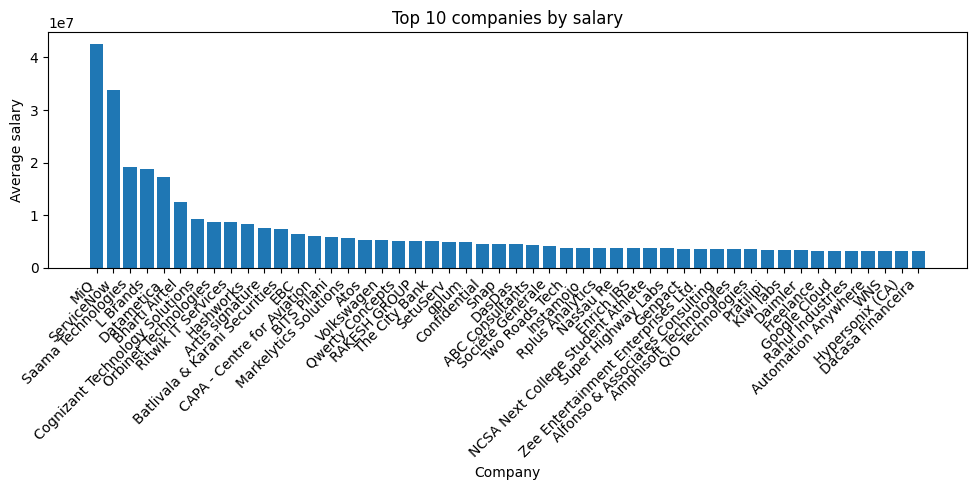

In [258]:
top_companies = (
    salary_price_dataset.groupby('Company Name')['Salary']
    .mean()
    .sort_values(ascending = False)
    .head(50)
)
plt.figure(figsize = (10, 5))
plt.bar(top_companies.index, top_companies.values)
plt.xticks(rotation = 45, ha = 'right')
plt.xlabel("Company")
plt.ylabel("Average salary")
plt.title("Top 10 companies by salary")
plt.tight_layout()
plt.show()

Average salary by job title

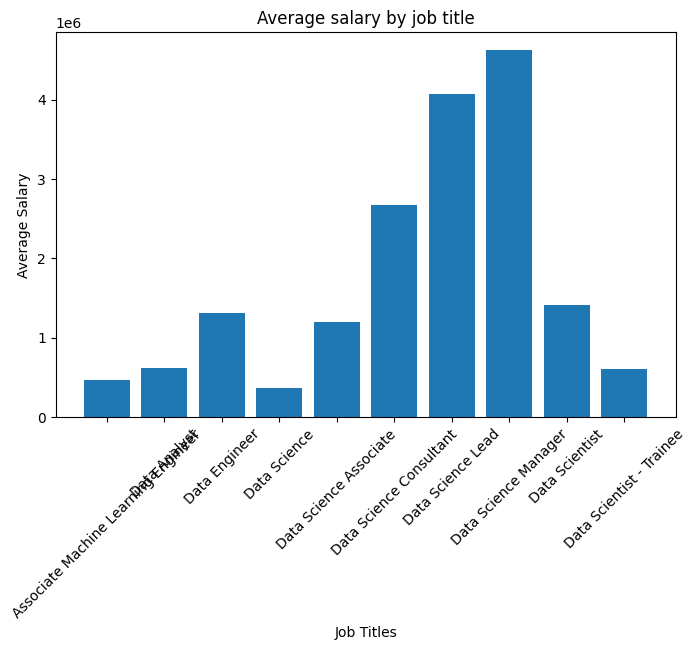

In [259]:
job_salary = salary_price_dataset.groupby('Job Title')['Salary'].mean().head(10)

plt.figure(figsize = (8, 5))
plt.bar(job_salary.index, job_salary.values)
plt.xlabel("Job Titles")
plt.ylabel("Average Salary")
plt.title("Average salary by job title")
plt.xticks(rotation = 45)
plt.show()

Number of employees (records) per job title

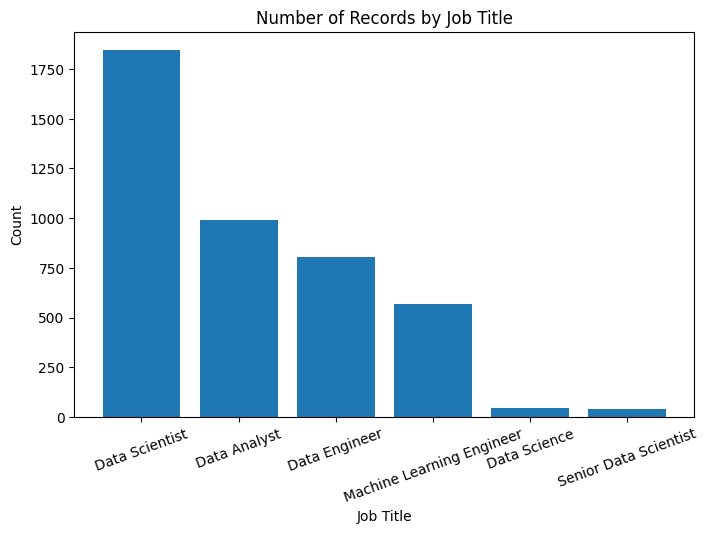

In [260]:
job_counts = salary_price_dataset['Job Title'].value_counts().head(6)

plt.figure(figsize=(8,5))
plt.bar(job_counts.index, job_counts.values)
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.title('Number of Records by Job Title')
plt.xticks(rotation=20)
plt.show()

Splitting the dataset into training set and testing set

In [261]:
X = salary_price_dataset[["Job Title"]]
y = salary_price_dataset["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

categorical_columns = ["Job Title"]
preprocessor = ColumnTransformer(
    transformers = [
        (
            "cat",
            OneHotEncoder(handle_unknown = "ignore"),
            categorical_columns
        )
    ],
    remainder = "passthrough"
)

Creating and training the linear regression model

In [262]:
linear_regression_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regression", LinearRegression())
])

linear_regression_model.fit(X_train, y_train)
prediction = linear_regression_model.predict(X_test)
print(f"Prediction: {prediction[:10]}")

Prediction: [ 793588.20718087 1483112.89037029  624648.00702119 1483112.89037029
 1483112.89037029 1483112.89037029 1483112.89037029  624648.00702119
  624648.00702119 1221218.47855242]


Evaluating the linear regression model

In [263]:
mae = mean_absolute_error(y_test, prediction)
mse = mean_squared_error(y_test, prediction)
r2 = r2_score(y_test, prediction)

print(f"Mean Absolute Error: {mae}")
print()
print(f"Mean Squared Error: {mse}")
print()
print(f"R2 Score: {r2}")
print()
print(f"The linear regression model is {r2 * 100}% accurate.")

Mean Absolute Error: 717024.9990446545

Mean Squared Error: 16791669489959.975

R2 Score: 0.0028166049480393696

The linear regression model is 0.28166049480393696% accurate.


In [264]:
salary_price_dataset.head()

,Unnamed: 0,Company Name,Job Title,Salaries Reported,Location,Salary
0,0,Mu Sigma,Data Scientist,105,Bangalore,648573.0
1,1,IBM,Data Scientist,95,Bangalore,1191950.0
2,2,Tata Consultancy Services,Data Scientist,66,Bangalore,836874.0
3,3,Impact Analytics,Data Scientist,40,Bangalore,669578.0
4,4,Accenture,Data Scientist,32,Bangalore,944110.0


In [265]:
salary_price_dataset["Salary"].describe()

,Salary
count,4.339000e+03
mean,1.119885e+06
std,4.300905e+06
min,1.081400e+04
25%,4.199380e+05
50%,7.062830e+05
75%,1.196675e+06
max,1.661404e+08
